In [5]:
import mne
import numpy as np
import matplotlib.pyplot as plt

print("MNE version:", mne.__version__)
print("All imports successful")

MNE version: 1.12.1
All imports successful


Extracting EDF parameters from data/physionet.org/files/chbmit/1.0.0/chb01/chb01_01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-06 11:42:54 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>
(23, 921600)


/var/folders/0s/hwlbxwsj5wg4tkpl6nmtqvmw0000gn/T/ipykernel_52818/3122925267.py:1: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf('data/physionet.org/files/chbmit/1.0.0/chb01/chb01_01.edf', preload=True)


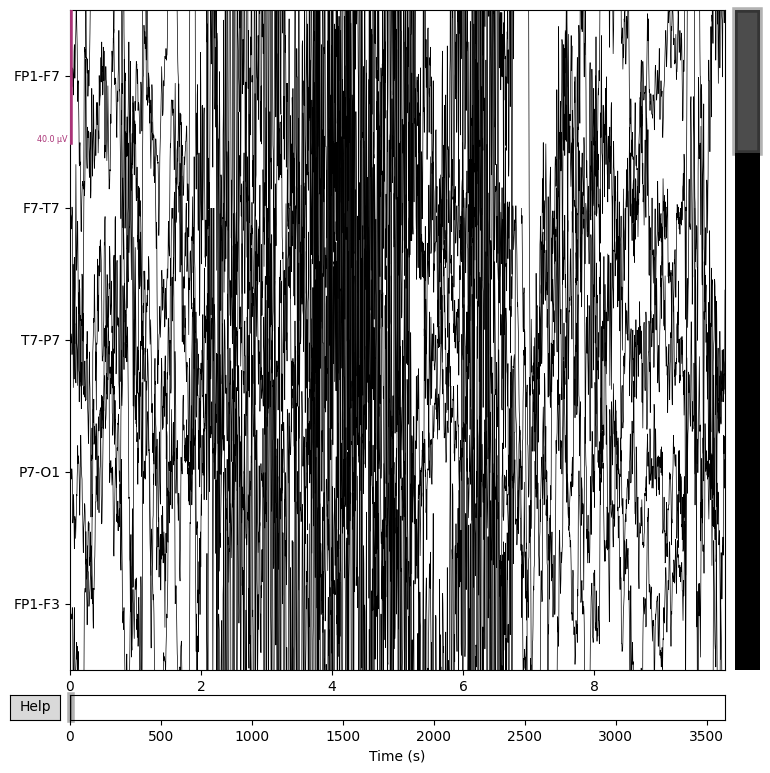

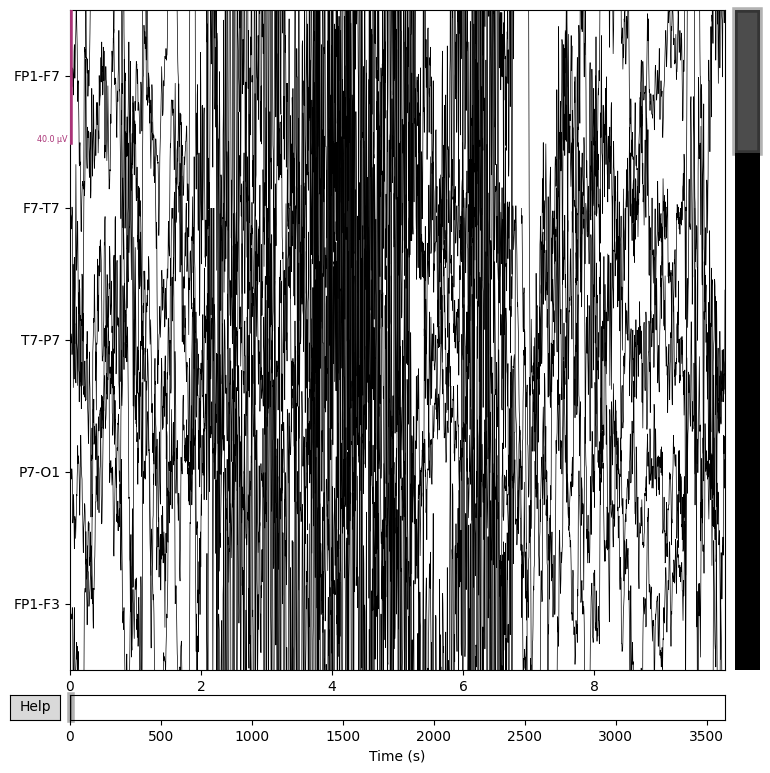

In [6]:
raw = mne.io.read_raw_edf('data/physionet.org/files/chbmit/1.0.0/chb01/chb01_01.edf', preload=True)
print(raw.info)
print(raw.get_data().shape)
raw.plot(duration=10, n_channels=5)

In [7]:
f = open('data/physionet.org/files/chbmit/1.0.0/chb01/chb01-summary.txt', 'r')
print(f.read())
f.close()

Data Sampling Rate: 256 Hz
*************************

Channels in EDF Files:
**********************
Channel 1: FP1-F7
Channel 2: F7-T7
Channel 3: T7-P7
Channel 4: P7-O1
Channel 5: FP1-F3
Channel 6: F3-C3
Channel 7: C3-P3
Channel 8: P3-O1
Channel 9: FP2-F4
Channel 10: F4-C4
Channel 11: C4-P4
Channel 12: P4-O2
Channel 13: FP2-F8
Channel 14: F8-T8
Channel 15: T8-P8
Channel 16: P8-O2
Channel 17: FZ-CZ
Channel 18: CZ-PZ
Channel 19: P7-T7
Channel 20: T7-FT9
Channel 21: FT9-FT10
Channel 22: FT10-T8
Channel 23: T8-P8

File Name: chb01_01.edf
File Start Time: 11:42:54
File End Time: 12:42:54
Number of Seizures in File: 0

File Name: chb01_02.edf
File Start Time: 12:42:57
File End Time: 13:42:57
Number of Seizures in File: 0

File Name: chb01_03.edf
File Start Time: 13:43:04
File End Time: 14:43:04
Number of Seizures in File: 1
Seizure Start Time: 2996 seconds
Seizure End Time: 3036 seconds

File Name: chb01_04.edf
File Start Time: 14:43:12
File End Time: 15:43:12
Number of Seizures in File: 1
S

In [8]:
raw_seizure = mne.io.read_raw_edf(
    'data/physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf',
    preload=True
)

print(raw_seizure.info)
print(f"Duration: {raw_seizure.times[-1]:.1f} seconds")

Extracting EDF parameters from data/physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-06 13:43:04 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>
Duration: 3600.0 seconds


/var/folders/0s/hwlbxwsj5wg4tkpl6nmtqvmw0000gn/T/ipykernel_52818/3497213716.py:1: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_seizure = mne.io.read_raw_edf(


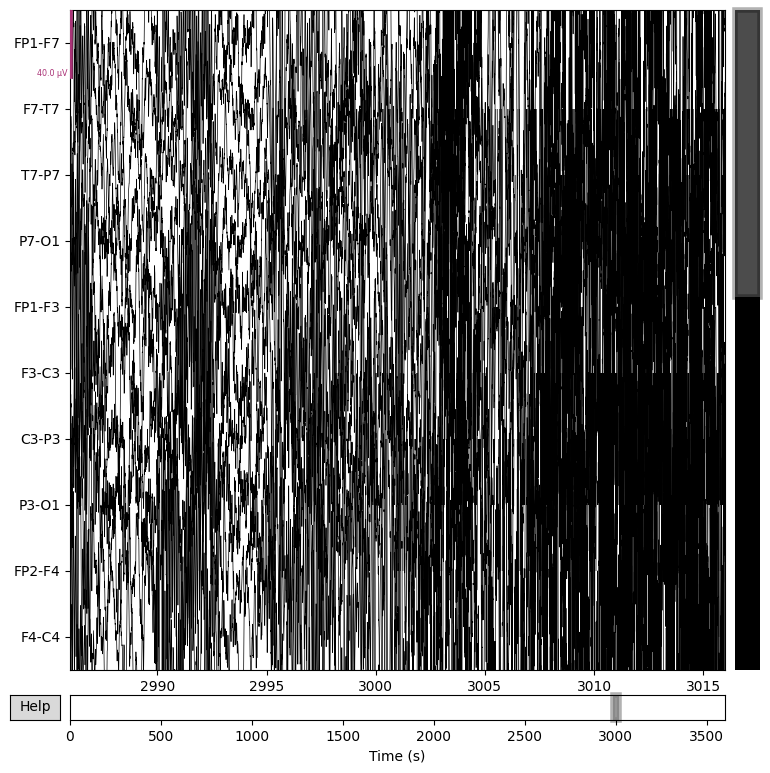

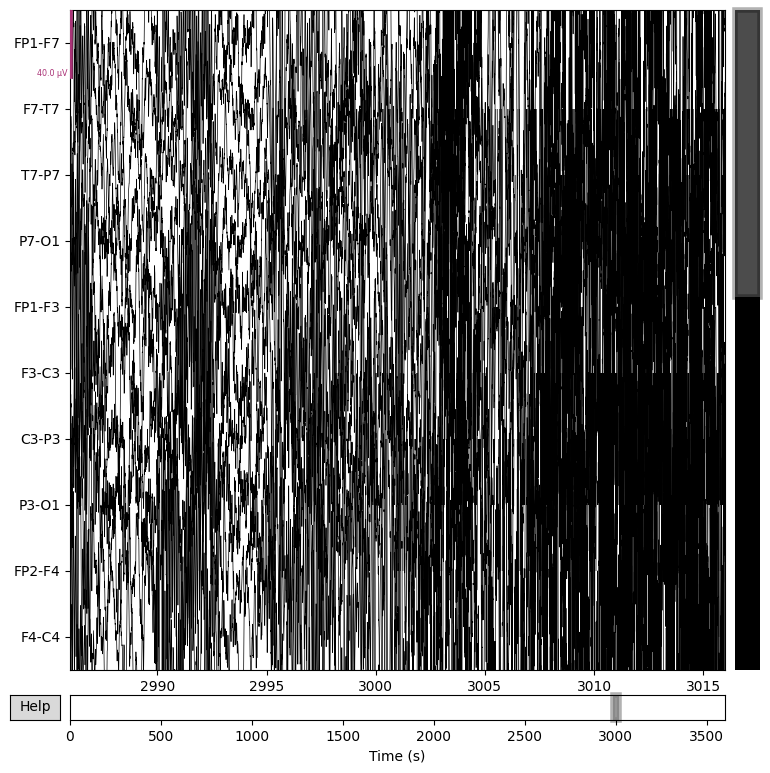

In [9]:
raw_seizure.plot(
    start=2986,
    duration=30,
    n_channels=10
)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)



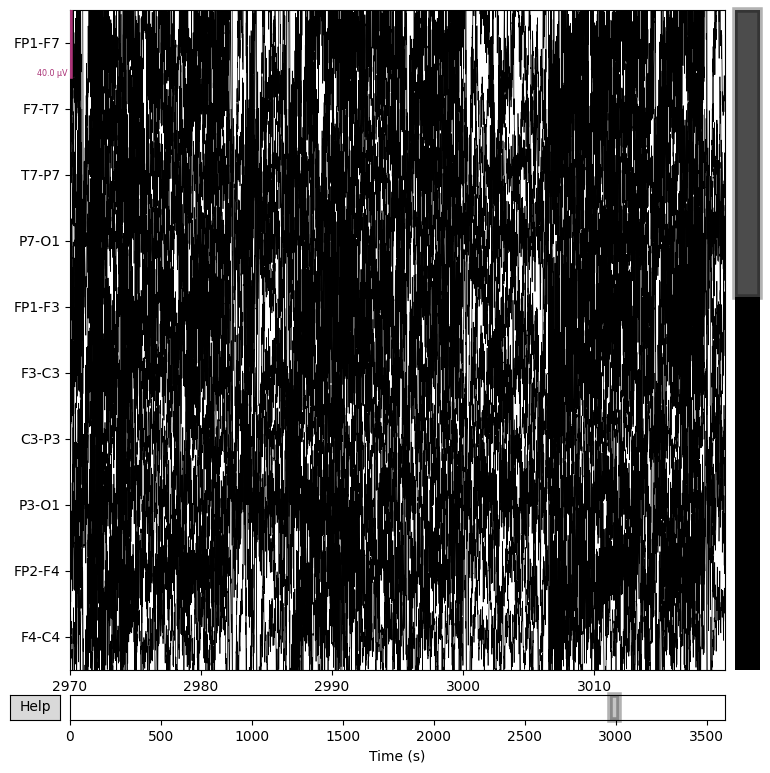

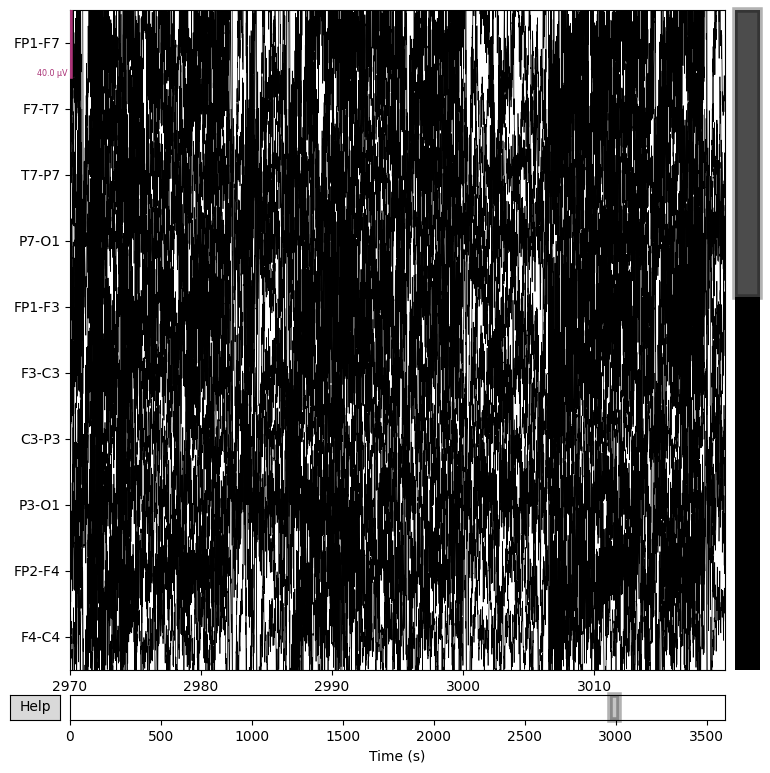

In [13]:
# --- Step 1: Bandpass Filter ---
raw_filtered = raw.copy().filter(l_freq=0.5, h_freq=40.0)

raw_filtered.plot(
    start=2970,       # before seizure onset at 2996s
    duration=50,      # view 10s pre-ictal → seizure → early post-ictal
    n_channels=10
)

In [14]:
import numpy as np

# --- Step 2: Epoching ---

sfreq = int(raw_filtered.info['sfreq'])  # 256 Hz
window_samples = 2 * sfreq               # 2 seconds = 512 samples

# Seizure onset and offset for chb01_03 (from summary file)
seizure_start_sec = 2996
seizure_end_sec   = 3036

# Convert to samples
seizure_start_sample = seizure_start_sec * sfreq
seizure_end_sample   = seizure_end_sec   * sfreq

# Get full data matrix (n_channels x n_samples)
data, times = raw_filtered[:, :]
n_channels, n_samples = data.shape

print(f"Sampling rate: {sfreq} Hz")
print(f"Window size: {window_samples} samples (2 seconds)")
print(f"Total samples in file: {n_samples}")
print(f"Seizure: sample {seizure_start_sample} to {seizure_end_sample}")

Sampling rate: 256 Hz
Window size: 512 samples (2 seconds)
Total samples in file: 921600
Seizure: sample 766976 to 777216


In [15]:
epochs = []   # will hold (n_channels x window_samples) arrays
labels = []   # 1 = seizure, 0 = interictal

step = window_samples  # no overlap for now

for start in range(0, n_samples - window_samples, step):
    end = start + window_samples
    window = data[:, start:end]

    # Label: ictal if window is fully inside the seizure period
    if start >= seizure_start_sample and end <= seizure_end_sample:
        labels.append(1)
    # Label: interictal if window ends at least 60s before seizure
    # (avoid ambiguous pre-ictal territory)
    elif end < (seizure_start_sample - 60 * sfreq):
        labels.append(0)
    else:
        # Skip ambiguous windows near seizure boundary
        continue

    epochs.append(window)

epochs = np.array(epochs)   # shape: (n_epochs, n_channels, window_samples)
labels = np.array(labels)

print(f"Total epochs: {len(epochs)}")
print(f"Seizure epochs (class 1): {np.sum(labels == 1)}")
print(f"Interictal epochs (class 0): {np.sum(labels == 0)}")
print(f"Epoch array shape: {epochs.shape}")

Total epochs: 1487
Seizure epochs (class 1): 20
Interictal epochs (class 0): 1467
Epoch array shape: (1487, 23, 512)


In [16]:
# --- Undersample interictal to match seizure count ---
rng = np.random.default_rng(seed=42)  # reproducible

ictal_idx     = np.where(labels == 1)[0]
interictal_idx = np.where(labels == 0)[0]

# Randomly pick same number of interictal as ictal
sampled_interictal_idx = rng.choice(
    interictal_idx,
    size=len(ictal_idx),
    replace=False
)

# Combine and shuffle
balanced_idx = np.concatenate([ictal_idx, sampled_interictal_idx])
balanced_idx = rng.permutation(balanced_idx)

epochs_balanced = epochs[balanced_idx]
labels_balanced = labels[balanced_idx]

print(f"Balanced dataset: {len(epochs_balanced)} total epochs")
print(f"Class 1 (ictal):      {np.sum(labels_balanced == 1)}")
print(f"Class 0 (interictal): {np.sum(labels_balanced == 0)}")
print(f"Final shape: {epochs_balanced.shape}")

Balanced dataset: 40 total epochs
Class 1 (ictal):      20
Class 0 (interictal): 20
Final shape: (40, 23, 512)


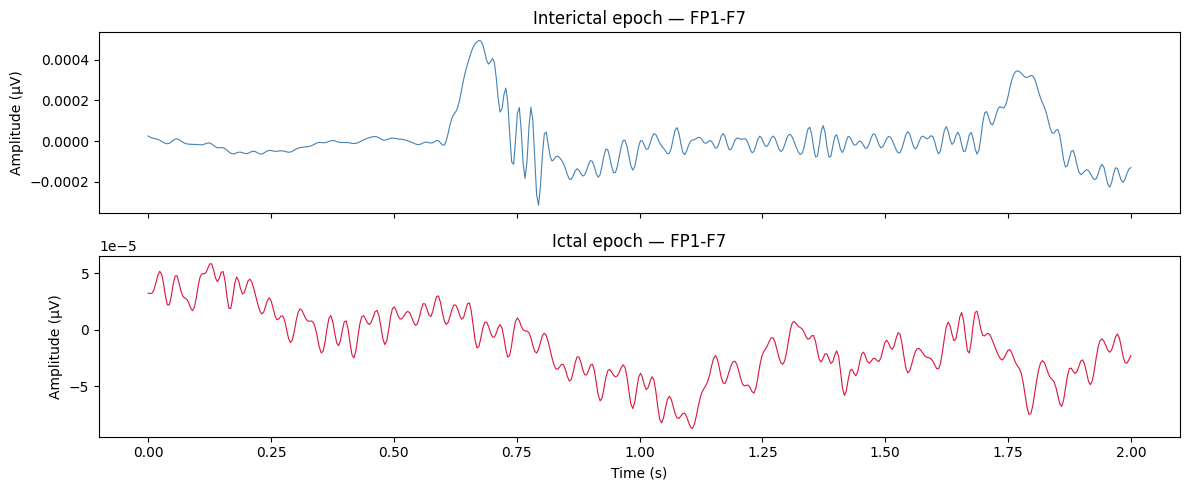

In [17]:
import matplotlib.pyplot as plt

# Pick one ictal and one interictal epoch
ictal_epoch     = epochs_balanced[labels_balanced == 1][0]   # shape: (23, 512)
interictal_epoch = epochs_balanced[labels_balanced == 0][0]  # shape: (23, 512)

# Plot channel FP1-F7 (index 0) for both — a frontal channel reactive to seizures
channel_idx = 0
channel_name = raw_filtered.ch_names[channel_idx]
t = np.linspace(0, 2, window_samples)  # 2 second time axis

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(t, interictal_epoch[channel_idx], color='steelblue', linewidth=0.8)
axes[0].set_title(f'Interictal epoch — {channel_name}')
axes[0].set_ylabel('Amplitude (µV)')

axes[1].plot(t, ictal_epoch[channel_idx], color='crimson', linewidth=0.8)
axes[1].set_title(f'Ictal epoch — {channel_name}')
axes[1].set_ylabel('Amplitude (µV)')
axes[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

In [19]:
from scipy.signal import welch

def extract_features(epoch, sfreq=256):
    """
    Extract band power and variance features from one epoch.
    
    Parameters
    ----------
    epoch : np.ndarray, shape (n_channels, n_samples)
    sfreq : int, sampling frequency in Hz
    
    Returns
    -------
    features : np.ndarray, shape (n_channels * 5,)
    """
    # Frequency bands of interest
    bands = {
        'delta': (0.5, 4.0),
        'theta': (4.0, 8.0),
        'alpha': (8.0, 13.0),
        'beta':  (13.0, 30.0),
    }
    
    features = []
    
    for ch_signal in epoch:  # iterate over channels
        
        # Compute power spectral density using Welch's method
        freqs, psd = welch(ch_signal, fs=sfreq, nperseg=sfreq)
        # freqs: array of frequency values
        # psd:   power at each frequency (µV²/Hz)
        
        # Extract band power for each band
        for band_name, (low, high) in bands.items():
            # Find which frequency bins fall inside this band
            band_mask = (freqs >= low) & (freqs <= high)
            # Integrate power across those bins (area under PSD curve)
            band_power = np.trapezoid(psd[band_mask], freqs[band_mask])
            features.append(band_power)
        
        # Signal variance (amplitude variability)
        features.append(np.var(ch_signal))
    
    return np.array(features)


# Apply to all epochs
X = np.array([extract_features(epoch) for epoch in epochs_balanced])
y = labels_balanced

print(f"Feature matrix shape: {X.shape}")
print(f"Expected: ({len(epochs_balanced)}, {23 * 5})")
print(f"Labels shape: {y.shape}")
print(f"\nExample feature vector (first epoch, first 10 features):")
print(X[0, :10])

Feature matrix shape: (40, 115)
Expected: (40, 115)
Labels shape: (40,)

Example feature vector (first epoch, first 10 features):
[6.37112564e-09 2.25480952e-09 2.14834682e-10 5.20580610e-10
 1.52523840e-08 1.36563092e-09 3.18420193e-10 4.30100321e-11
 5.34340570e-11 2.96816224e-09]


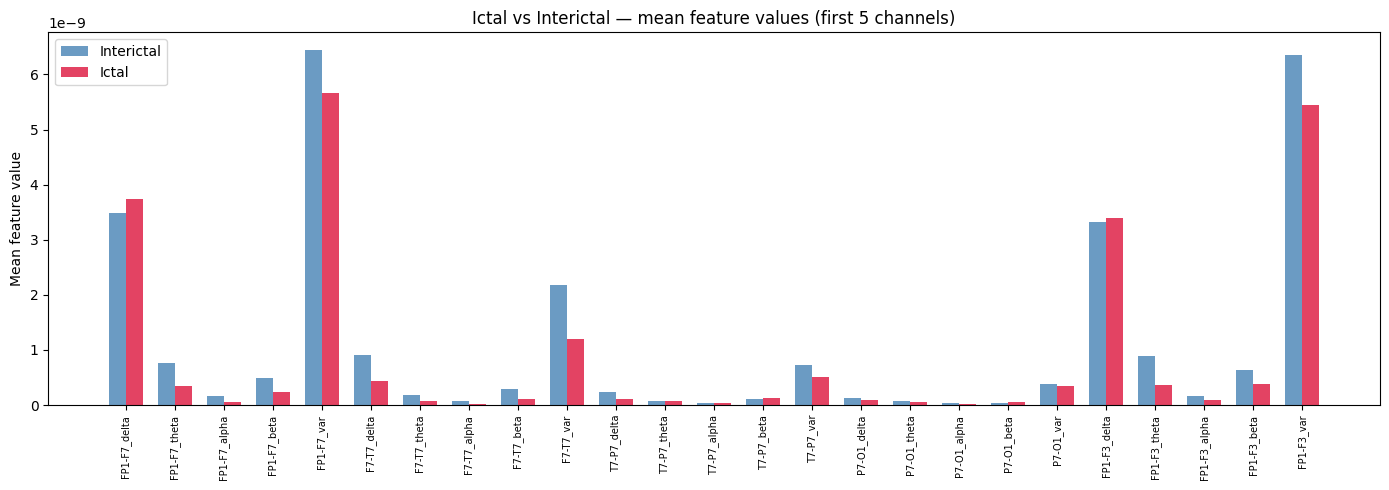

In [20]:
# --- Visualize feature separation ---
import matplotlib.pyplot as plt

# Average each feature across ictal vs interictal epochs
ictal_mean     = X[y == 1].mean(axis=0)
interictal_mean = X[y == 0].mean(axis=0)

# Feature names for x axis
band_names = ['delta', 'theta', 'alpha', 'beta', 'var']
ch_names_short = [raw_filtered.ch_names[i] for i in range(23)]
feature_names = [f"{ch}_{b}" for ch in ch_names_short for b in band_names]

# Plot first 25 features (first 5 channels) for readability
n_show = 25
x = np.arange(n_show)
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, interictal_mean[:n_show], width, label='Interictal', color='steelblue', alpha=0.8)
ax.bar(x + width/2, ictal_mean[:n_show],      width, label='Ictal',      color='crimson',   alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(feature_names[:n_show], rotation=90, fontsize=7)
ax.set_ylabel('Mean feature value')
ax.set_title('Ictal vs Interictal — mean feature values (first 5 channels)')
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Step 4: Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # reproducible split
    stratify=y          # keep class balance in both splits
)

print(f"Training set: {X_train.shape[0]} epochs")
print(f"Test set:     {X_test.shape[0]} epochs")
print(f"Train class balance: {y_train.sum()} ictal, {(y_train==0).sum()} interictal")
print(f"Test class balance:  {y_test.sum()} ictal, {(y_test==0).sum()} interictal")


Training set: 32 epochs
Test set:     8 epochs
Train class balance: 16 ictal, 16 interictal
Test class balance:  4 ictal, 4 interictal


Classification Report:
              precision    recall  f1-score   support

  Interictal       0.50      1.00      0.67         4
       Ictal       0.00      0.00      0.00         4

    accuracy                           0.50         8
   macro avg       0.25      0.50      0.33         8
weighted avg       0.25      0.50      0.33         8



/Users/petra/seizure-detection/neuro/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/petra/seizure-detection/neuro/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/petra/seizure-detection/neuro/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

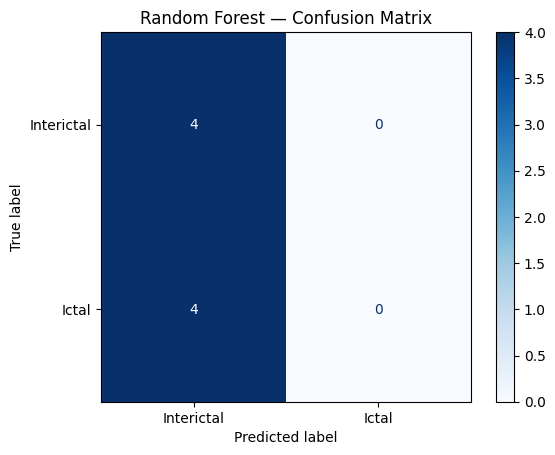

In [22]:
# --- Step 5: Train Random Forest ---
rf = RandomForestClassifier(
    n_estimators=500,    # number of trees
    max_depth=None,      # trees grow until leaves are pure
    random_state=42,
    class_weight='balanced'  # extra safety net for any residual imbalance
)

rf.fit(X_train, y_train)

# --- Evaluate ---
y_pred = rf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Interictal', 'Ictal']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Interictal', 'Ictal'])
disp.plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.show()

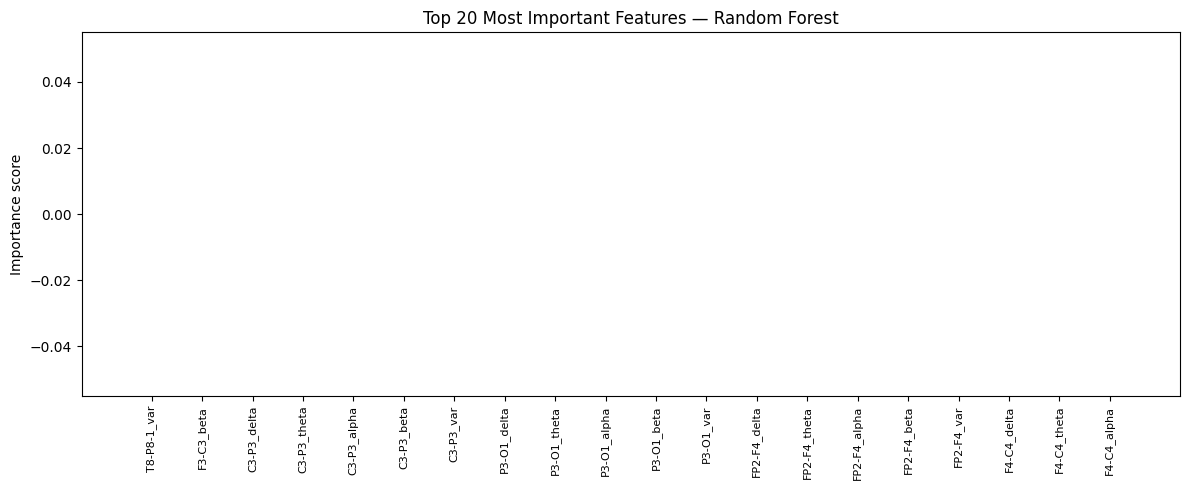

In [23]:
# --- Feature Importances ---
importances = rf.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]  # top 20 features

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(20), importances[top_idx], color='steelblue', alpha=0.8)
ax.set_xticks(range(20))
ax.set_xticklabels([feature_names[i] for i in top_idx], rotation=90, fontsize=8)
ax.set_ylabel('Importance score')
ax.set_title('Top 20 Most Important Features — Random Forest')
plt.tight_layout()
plt.show()

In [24]:
print(f"Number of features in model: {len(rf.feature_importances_)}")
print(f"Number of feature names: {len(feature_names)}")
print(f"Top 5 importance scores: {importances[top_idx[:5]]}")

Number of features in model: 115
Number of feature names: 115
Top 5 importance scores: [0. 0. 0. 0. 0.]


In [25]:
## Random Forest — Cross Validation (correct approach for small datasets)
#Note: train/test split approach failed due to insufficient data (40 epochs). 
#Cross-validation is the statistically appropriate method for datasets this size.
    

In [26]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight='balanced'
)

scores = cross_val_score(rf_cv, X, y, cv=cv, scoring='f1')

print(f"F1 scores per fold: {scores.round(3)}")
print(f"Mean F1: {scores.mean():.3f} ± {scores.std():.3f}")

F1 scores per fold: [0.    0.    0.667 0.    0.   ]
Mean F1: 0.133 ± 0.267


Top 10 most important features:
  T8-P8-1_var: 0.0000
  F3-C3_beta: 0.0000
  C3-P3_delta: 0.0000
  C3-P3_theta: 0.0000
  C3-P3_alpha: 0.0000
  C3-P3_beta: 0.0000
  C3-P3_var: 0.0000
  P3-O1_delta: 0.0000
  P3-O1_theta: 0.0000
  P3-O1_alpha: 0.0000


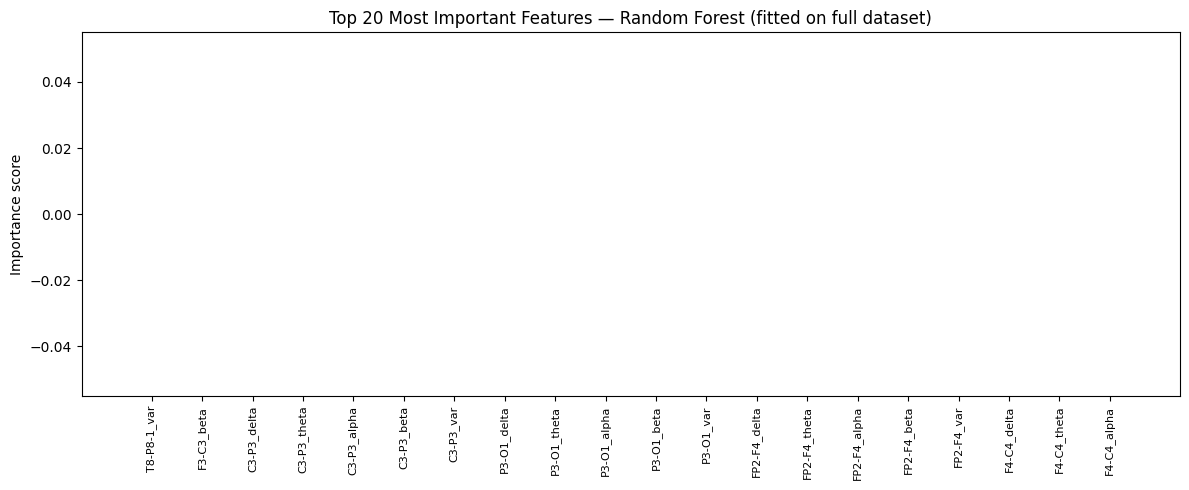

In [27]:
# Fit on full dataset to inspect what the model learns
rf_cv.fit(X, y)

importances = rf_cv.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]

print("Top 10 most important features:")
for i in top_idx[:10]:
    print(f"  {feature_names[i]}: {importances[i]:.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(20), importances[top_idx], color='steelblue', alpha=0.8)
ax.set_xticks(range(20))
ax.set_xticklabels([feature_names[i] for i in top_idx], rotation=90, fontsize=8)
ax.set_ylabel('Importance score')
ax.set_title('Top 20 Most Important Features — Random Forest (fitted on full dataset)')
plt.tight_layout()
plt.show()

In [28]:

print("Any NaNs in X:", np.any(np.isnan(X)))
print("Any infs in X:", np.any(np.isinf(X)))
print("Any all-zero rows:", np.any(np.all(X == 0, axis=1)))
print("Feature value range:", X.min(), "to", X.max())
print("Feature std across epochs:", X.std(axis=0).mean())
print("\nClass 0 mean delta (feature 0):", X[y==0, 0].mean())
print("Class 1 mean delta (feature 0):", X[y==1, 0].mean())

Any NaNs in X: False
Any infs in X: False
Any all-zero rows: False
Feature value range: 2.9468557643106852e-12 to 3.261928866269464e-08
Feature std across epochs: 6.589441866196681e-10

Class 0 mean delta (feature 0): 3.483919500777647e-09
Class 1 mean delta (feature 0): 3.736270032438095e-09


In [29]:
from sklearn.preprocessing import RobustScaler

# RobustScaler uses median and IQR — resistant to outliers like your artifact epoch
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print("After scaling:")
print(f"Class 0 mean delta (feature 0): {X_scaled[y==0, 0].mean():.4f}")
print(f"Class 1 mean delta (feature 0): {X_scaled[y==1, 0].mean():.4f}")
print(f"Feature std across epochs: {X_scaled.std(axis=0).mean():.4f}")

# Rerun cross validation on scaled features
scores_scaled = cross_val_score(rf_cv, X_scaled, y, cv=cv, scoring='f1')
print(f"\nF1 scores per fold: {scores_scaled.round(3)}")
print(f"Mean F1: {scores_scaled.mean():.3f} ± {scores_scaled.std():.3f}")

After scaling:
Class 0 mean delta (feature 0): 0.7255
Class 1 mean delta (feature 0): 0.7823
Feature std across epochs: 1.7242

F1 scores per fold: [1.    1.    0.889 1.    0.857]
Mean F1: 0.949 ± 0.063


Top 10 most important features:
  FT9-FT10_beta: 0.0770
  P3-O1_beta: 0.0683
  P8-O2_beta: 0.0680
  C4-P4_beta: 0.0634
  P7-O1_beta: 0.0457
  P4-O2_beta: 0.0456
  FT9-FT10_theta: 0.0305
  T7-FT9_beta: 0.0301
  F4-C4_beta: 0.0209
  FT9-FT10_var: 0.0197


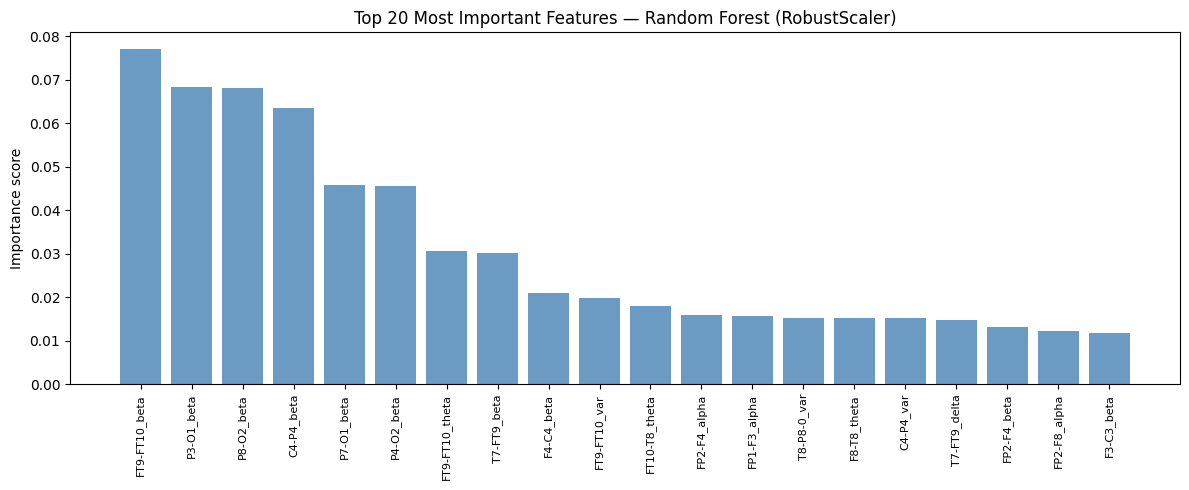

In [30]:
rf_cv.fit(X_scaled, y)

importances = rf_cv.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]

print("Top 10 most important features:")
for i in top_idx[:10]:
    print(f"  {feature_names[i]}: {importances[i]:.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(20), importances[top_idx], color='steelblue', alpha=0.8)
ax.set_xticks(range(20))
ax.set_xticklabels([feature_names[i] for i in top_idx], rotation=90, fontsize=8)
ax.set_ylabel('Importance score')
ax.set_title('Top 20 Most Important Features — Random Forest (RobustScaler)')
plt.tight_layout()
plt.show()

In [31]:
import os
os.makedirs('/Users/petra/seizure-detection/data', exist_ok=True)
np.save('/Users/petra/seizure-detection/data/epochs_balanced.npy', epochs_balanced)
np.save('/Users/petra/seizure-detection/data/labels_balanced.npy', labels_balanced)
print("Saved successfully")

Saved successfully
